<a href="https://colab.research.google.com/github/Mahendra-69/CSL701-CS09_Machine-Learning-Lab/blob/main/Expriments/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Mahendra R. Choudhari
  ,   Roll No:CS09

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias

### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [4]:
# Task 1: Import Libraries and Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load your Iris CSV file
df = pd.read_csv('/content/Iris.csv')

# Display the dataset
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


# Task 2: Explore the Dataset

In [6]:
# Task 2: Explore the Dataset

print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nFirst 5 Rows:")
print(df.head())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['Species'].value_counts())

Dataset Shape:
(150, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

First 5 Rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6  

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [7]:
# Task 3: Select Features and Target

# Remove the Id column and Species column from input features
X = df.drop(['Id', 'Species'], axis=1)

# Select Species as the target
y = df['Species']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object

Feature Shape: (150, 4)
Target Shape: (150,)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [8]:
# Task 4: Split and Scale the Data

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create StandardScaler
scaler = StandardScaler()

# Scale the training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale the testing data
X_test_scaled = scaler.transform(X_test)

# Display the shapes
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

print("\nFirst 5 rows of scaled training data:")
print(X_train_scaled[:5])

Training Features Shape: (120, 4)
Testing Features Shape: (30, 4)
Training Target Shape: (120,)
Testing Target Shape: (30,)

First 5 rows of scaled training data:
[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]]


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [9]:
# Task 5: Implement Linear SVM

# Create Linear SVM model
svm_model = SVC(kernel='linear')

# Train the SVM model
svm_model.fit(X_train_scaled, y_train)

# Make predictions on test data
y_pred_svm = svm_model.predict(X_test_scaled)

# Display predictions
print("First 20 Predictions:")
print(y_pred_svm[:20])

print("\nActual Values:")
print(y_test.values[:20])

First 20 Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica']

Actual Values:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica']


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [10]:
# Task 6: Evaluate SVM

# Calculate accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:")
print(svm_accuracy)

# Generate confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("\nConfusion Matrix:")
print(cm_svm)

# Generate classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_svm
))

SVM Accuracy:
1.0

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

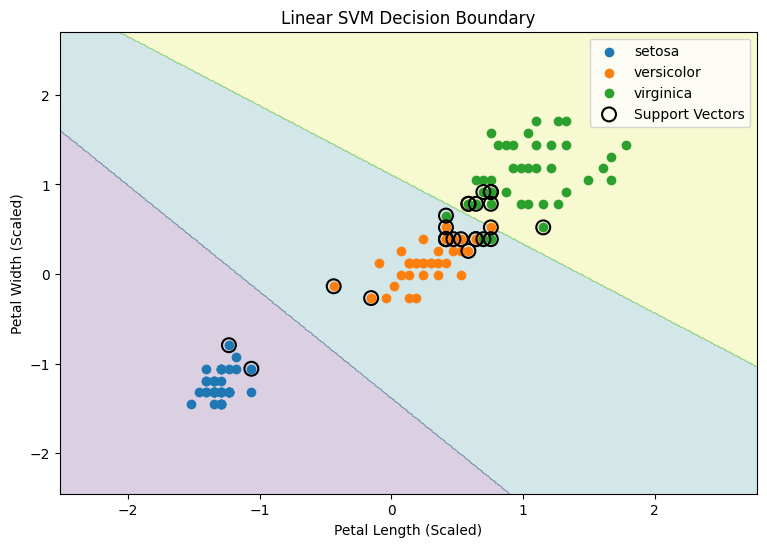

Number of Support Vectors: 25


In [12]:
# Task 7: Visualize SVM Decision Boundary

# Select Petal Length and Petal Width
X_2d = df[['PetalLengthCm', 'PetalWidthCm']]

# Convert species names to numbers only for visualization
species_mapping = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}

y_2d = df['Species'].map(species_mapping)

# Split the 2-D dataset
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

# Scale the 2-D data
scaler_2d = StandardScaler()

X2_train_scaled = scaler_2d.fit_transform(X2_train)
X2_test_scaled = scaler_2d.transform(X2_test)

# Train Linear SVM
svm_2d = SVC(kernel='linear')

svm_2d.fit(X2_train_scaled, y2_train)

# Create mesh grid
x_min = X2_train_scaled[:, 0].min() - 1
x_max = X2_train_scaled[:, 0].max() + 1

y_min = X2_train_scaled[:, 1].min() - 1
y_max = X2_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict class for every point in the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = svm_2d.predict(grid_points)

Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(9, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2
)

# Plot training data
for class_value in [0, 1, 2]:
    plt.scatter(
        X2_train_scaled[y2_train == class_value, 0],
        X2_train_scaled[y2_train == class_value, 1],
        label=iris.target_names[class_value]
    )

# Plot support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors='none',
    edgecolors='black',
    linewidths=1.5,
    label='Support Vectors'
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

# Display number of support vectors
print("Number of Support Vectors:", len(svm_2d.support_vectors_))

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

Logistic Regression Accuracy:
0.9333333333333333


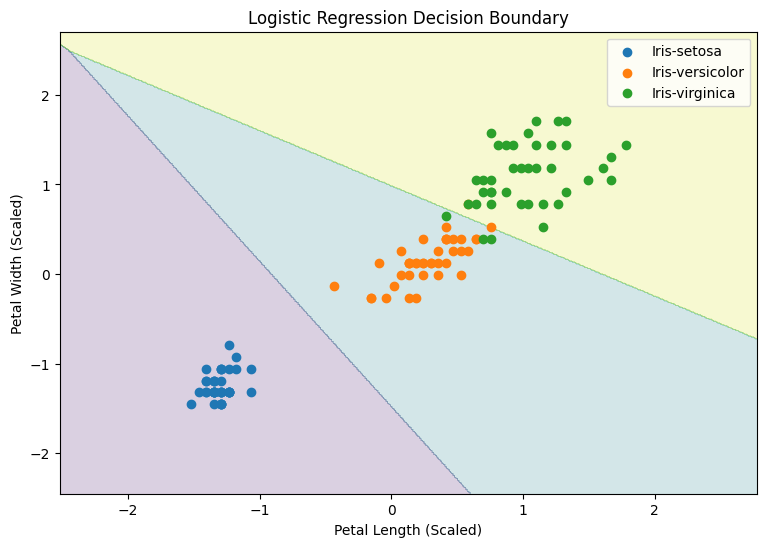

In [14]:
# Task 8: Normal Linear Classifier using Logistic Regression

# Define class names
class_names = [
    'Iris-setosa',
    'Iris-versicolor',
    'Iris-virginica'
]

# Create Logistic Regression model
logistic_model = LogisticRegression(max_iter=200)

# Train the model
logistic_model.fit(X2_train_scaled, y2_train)

# Make predictions
y2_pred_logistic = logistic_model.predict(X2_test_scaled)

# Calculate accuracy
logistic_accuracy = accuracy_score(y2_test, y2_pred_logistic)

print("Logistic Regression Accuracy:")
print(logistic_accuracy)

# Predict classes for the mesh grid
Z_logistic = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z_logistic = Z_logistic.reshape(xx.shape)

# Plot Logistic Regression decision boundary
plt.figure(figsize=(9, 6))

plt.contourf(
    xx,
    yy,
    Z_logistic,
    alpha=0.2
)

# Plot training data
for class_value in [0, 1, 2]:
    plt.scatter(
        X2_train_scaled[y2_train == class_value, 0],
        X2_train_scaled[y2_train == class_value, 1],
        label=class_names[class_value]
    )

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

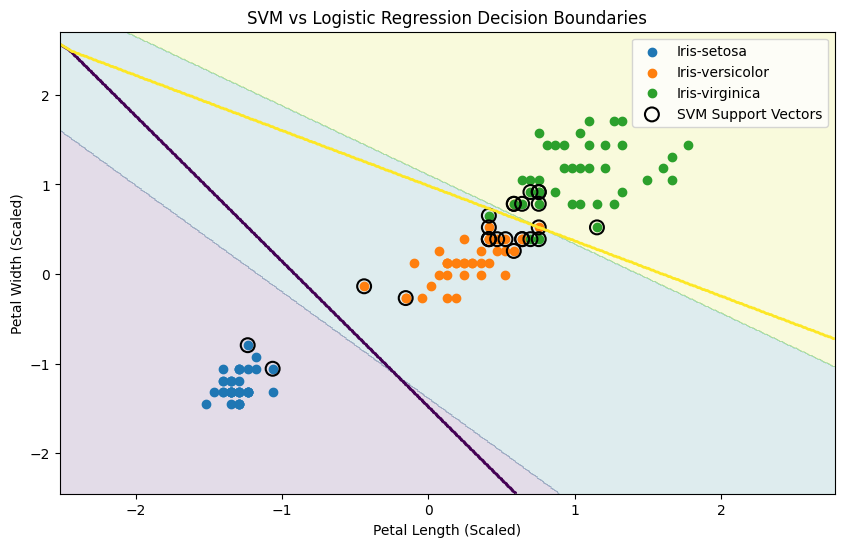

In [15]:
# Task 9: Compare SVM and Logistic Regression Decision Boundaries

plt.figure(figsize=(10, 6))

# Plot SVM decision regions
Z_svm = svm_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)
Z_svm = Z_svm.reshape(xx.shape)

plt.contourf(
    xx,
    yy,
    Z_svm,
    alpha=0.15
)

# Plot Logistic Regression decision regions
Z_logistic = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)
Z_logistic = Z_logistic.reshape(xx.shape)

plt.contour(
    xx,
    yy,
    Z_logistic,
    levels=[0.5, 1.5],
    linewidths=2
)

# Plot training data
for class_value in [0, 1, 2]:
    plt.scatter(
        X2_train_scaled[y2_train == class_value, 0],
        X2_train_scaled[y2_train == class_value, 1],
        label=class_names[class_value]
    )

# Plot SVM support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors='none',
    edgecolors='black',
    linewidths=1.5,
    label='SVM Support Vectors'
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("SVM vs Logistic Regression Decision Boundaries")
plt.legend()
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [17]:
# Task 10: Compare Performance

# SVM predictions
y2_pred_svm = svm_2d.predict(X2_test_scaled)

# -------------------------------
# Accuracy
# -------------------------------

svm_accuracy_2d = accuracy_score(y2_test, y2_pred_svm)
logistic_accuracy = accuracy_score(y2_test, y2_pred_logistic)

print("Performance Comparison:")
print("-----------------------")

print("Linear SVM Accuracy:", svm_accuracy_2d)
print("Logistic Regression Accuracy:", logistic_accuracy)


# -------------------------------
# Confusion Matrix
# -------------------------------

print("\nLinear SVM Confusion Matrix:")
print(confusion_matrix(y2_test, y2_pred_svm))

print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y2_test, y2_pred_logistic))


# -------------------------------
# Classification Report
# -------------------------------

print("\nLinear SVM Classification Report:")
print(classification_report(
    y2_test,
    y2_pred_svm,
    target_names=class_names
))

print("\nLogistic Regression Classification Report:")
print(classification_report(
    y2_test,
    y2_pred_logistic,
    target_names=class_names
))


# -------------------------------
# Final Comparison
# -------------------------------

if svm_accuracy_2d > logistic_accuracy:
    print("Linear SVM performed better.")
elif logistic_accuracy > svm_accuracy_2d:
    print("Logistic Regression performed better.")
else:
    print("Both models performed equally.")

Performance Comparison:
-----------------------
Linear SVM Accuracy: 0.9333333333333333
Logistic Regression Accuracy: 0.9333333333333333

Linear SVM Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Logistic Regression Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Linear SVM Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


Logistic Regression Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       ac

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.